# 🛠️ 설비 상태 변화 & 다중 센서 패턴 분석

**학습 범위**
- 23_01 상태 변화 추적
- 23_02 다중센서 패턴 분석

> 구성  
> **개념 → 코드 → 실행 결과 → 그래프 → 그래프 읽는 법 → 상황별 코드 선택 → 주의점 → 리포트**

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 851 ('font.family : Malgun Gothic')
Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 852 ('axes.unicode_minus : False')


✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 1. 📌 한 줄 요약

설비 상태 분석의 핵심은 **값 하나가 큰지 작은지**보다, 시간이 흐르면서 **추세·흔들림·급변·센서 간 관계가 평소와 어떻게 달라지는지**를 보는 것입니다.

이번 단원은 아래 흐름으로 연결됩니다.

```text
한 엔진 선택
→ 원본 센서 확인
→ 이동평균으로 추세
→ 이동표준편차로 변동성
→ diff / pct_change로 급변
→ 변화점 후보 찾기
→ 여러 센서 정규화
→ 함께/반대로 움직이는 패턴 확인
→ corr / heatmap
→ 여러 신호가 겹치는 구간 찾기
→ 정비 언어로 리포트
```

## 2. 🗂️ 핵심 목차

- **A. 상태 변화의 관점**
  - 절대값보다 흐름
  - 정상 → 열화 패턴
  - 한 설비씩 분석
- **B. 이동통계**
  - `rolling().mean()`
  - `rolling().std()`
  - window 선택
  - `min_periods`
- **C. 변화량과 변화점**
  - `diff()`
  - `pct_change()`
  - 잔차 기반 변화점
  - 임계값
- **D. 시간 인덱싱과 리샘플링**
  - cycle vs timestamp
  - `to_datetime()`
  - `.loc[]`
  - `resample()`
- **E. 다중 센서**
  - Min-Max 정규화
  - 이동평균 후 겹쳐 보기
  - 초반/후반 변화 폭
- **F. 상관관계**
  - `corr()`
  - `heatmap()`
  - 강한 양/음 상관
  - 상관 ≠ 인과
- **G. 종합 판단**
  - 추세 꺾임
  - 변동성 증가
  - 변화점 집중
  - 관계 변화
  - 정비 리포트

## 3. 💻 한눈에 보는 코드

| 알고 싶은 것 | 핵심 코드 | 그래프에서 볼 것 |
|---|---|---|
| 한 설비만 보기 | `df[df["unit_number"] == 2]` | 다른 엔진과 섞이지 않았는가 |
| 시간 순 정렬 | `.sort_values("time_cycles")` | x축이 순서대로 증가하는가 |
| 추세 | `.rolling(10).mean()` | 선의 방향과 기울기 |
| 변동성 | `.rolling(10).std()` | 흔들림 크기가 커지는가 |
| 급변 | `.diff()` | 0에서 멀리 튀는 봉우리 |
| 변화율 | `.pct_change()` | 상대적으로 몇 % 변했는가 |
| 잔차 | `s - s.rolling(w).mean()` | 평소 기준선에서 얼마나 벗어났나 |
| 변화점 후보 | `abs(residual) > k*std` | 후보가 어느 구간에 몰리는가 |
| 날짜형 변환 | `pd.to_datetime()` | datetime으로 바뀌었는가 |
| 기간 자르기 | `.loc["2024-01-02":"2024-01-03"]` | 의심 기간만 집중 분석 |
| 시간 집계 | `.resample("D").mean()` | 큰 흐름 |
| 최대 피크 | `.resample("D").max()` | 평균에 묻힌 위험 순간 |
| 센서 눈금 맞추기 | `(x-x.min())/(x.max()-x.min())` | 변화 모양 비교 |
| 센서 관계 | `.corr()` | + / - 방향과 강도 |
| 관계 시각화 | `sns.heatmap()` | 진한 색 덩어리 |

## 4. ⚠️ 강의자료 결과와 이 노트의 실행 결과 구분

강의자료에는 다음 **예상 결과**가 명시되어 있습니다.

- 전체 1036행, 엔진 5대
- 2번 엔진 287행
- 이동표준편차 후반 평균이 초반보다 크게 증가하는 예
- 잔차 기반 변화점 예: 임계값 약 16.3, 변화점 13개
- `sensor_2` ↔ `sensor_7` 강한 음의 상관 약 `-0.96`
- `sensor_2` ↔ `sensor_11` 강한 양의 상관 약 `+0.84`
- 종합 분석 예: 변화점 19개, 216~288 구간 집중

하지만 **이번 첨부에는 실제 CSV가 포함되어 있지 않습니다.**

따라서 아래 실행 그래프는 개념을 직접 볼 수 있도록 만든 **합성 데모 데이터**입니다.  
강의자료의 예상값을 실제 데이터 계산값처럼 재현했다고 주장하지 않습니다.

# 5. 🧪 실행 가능한 합성 설비 데이터

다음 특징을 가진 C-MAPSS 느낌의 합성 데이터를 만듭니다.

- 엔진 3대
- 각 엔진은 cycle 순으로 진행
- 후반부에 추세가 바뀜
- 후반부에 변동성이 증가
- 일부 센서는 함께 상승
- 일부 센서는 반대로 하락

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_OK = True
except ImportError:
    SEABORN_OK = False

np.random.seed(7)

rows = []

for unit in [1, 2, 3]:
    n = {1: 210, 2: 287, 3: 235}[unit]

    for cycle in range(1, n + 1):
        # 후반부 열화 진행률
        start_change = int(n * 0.62)
        progress = max(0, cycle - start_change)

        # 후반부로 갈수록 노이즈 증가
        noise_scale = 0.8 + 0.012 * progress

        sensor_2 = (
            642
            + 0.012 * cycle
            + 0.055 * progress
            + np.random.normal(0, noise_scale)
        )

        # sensor_2와 강한 양의 관계
        sensor_11 = (
            46
            + 0.035 * (sensor_2 - 642)
            + np.random.normal(0, 0.08 + 0.002 * progress)
        )

        # sensor_2와 반대 방향
        sensor_7 = (
            554
            - 0.18 * (sensor_2 - 642)
            + np.random.normal(0, 0.25 + 0.003 * progress)
        )

        # 변동성이 후반에 커지는 센서
        sensor_3 = (
            1588
            + 0.02 * cycle
            + 0.03 * progress
            + np.random.normal(0, 2.0 + 0.045 * progress)
        )

        # 다른 패턴의 센서
        sensor_4 = (
            1400
            + 0.025 * cycle
            + 0.04 * progress
            + np.random.normal(0, 1.3)
        )

        sensor_20 = (
            39
            - 0.004 * cycle
            - 0.018 * progress
            + np.random.normal(0, 0.12)
        )

        rows.append({
            "unit_number": unit,
            "time_cycles": cycle,
            "sensor_2": sensor_2,
            "sensor_3": sensor_3,
            "sensor_4": sensor_4,
            "sensor_7": sensor_7,
            "sensor_11": sensor_11,
            "sensor_20": sensor_20,
        })

df = pd.DataFrame(rows)

print("합성 데이터 크기:", df.shape)
print("엔진 목록:", sorted(df["unit_number"].unique()))
display(df.head())

합성 데이터 크기: (732, 8)
엔진 목록: [np.int64(1), np.int64(2), np.int64(3)]


,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_20
0,1,1,643.364421,1588.835033,1398.999400,553.762609,46.010480,38.996248
1,1,2,642.023288,1589.240997,1399.236942,554.250223,45.860437,38.971414
2,1,3,642.440239,1585.153517,1400.795954,553.860070,45.994500,39.002866
3,1,4,642.267568,1588.388671,1399.596718,554.364513,45.887243,39.227489
4,1,5,642.023691,1583.523370,1401.489216,553.894429,45.884775,38.930023


# 6. 👀 그래프를 보기 전에 먼저 알아야 하는 관점

강의자료의 핵심은 **“한 점이 크다”가 아니라 “평소 흐름에서 어떻게 달라졌는가”**입니다.

그래프를 볼 때 처음부터 아래 4가지를 순서대로 봅니다.

```text
① 방향   : 올라가나? 내려가나? 평평한가?
② 흔들림 : 출렁임이 커지나?
③ 급변   : 갑자기 튀는 점이 있나?
④ 시점   : 언제부터 달라졌나?
```

이 네 가지를 먼저 보면 그래프가 훨씬 덜 막막합니다.

## 6-1. 반드시 한 엔진씩 보기

여러 엔진을 이어서 그리면  
**1번 엔진 고장 직전 → 2번 엔진 초기 상태**가 연결되면서 가짜 급락이 생길 수 있습니다.

In [3]:
engine = (
    df[df["unit_number"] == 2]
    .sort_values("time_cycles")
    .reset_index(drop=True)
    .copy()
)

print("2번 엔진 행 수:", len(engine))
display(engine.head())

2번 엔진 행 수: 287


,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_20
0,2,1,642.645542,1589.133807,1398.966768,553.920782,46.163269,39.054961
1,2,2,642.682118,1589.621597,1397.763429,553.748991,45.904832,38.947132
2,2,3,642.516558,1588.169676,1401.232512,553.807856,45.882835,38.834552
3,2,4,642.935608,1590.406441,1400.543028,554.130802,46.057200,39.042290
4,2,5,640.668442,1587.403982,1401.338211,553.988352,45.845384,38.765990


## 6-2. 원본 센서 그래프 — 무엇을 봐야 하나?

이 그래프에서는 숫자 하나보다:

- 초반과 후반의 **중심 위치**
- 후반의 **흔들림 크기**
- 흐름이 달라지기 시작한 **시점**

을 봅니다.

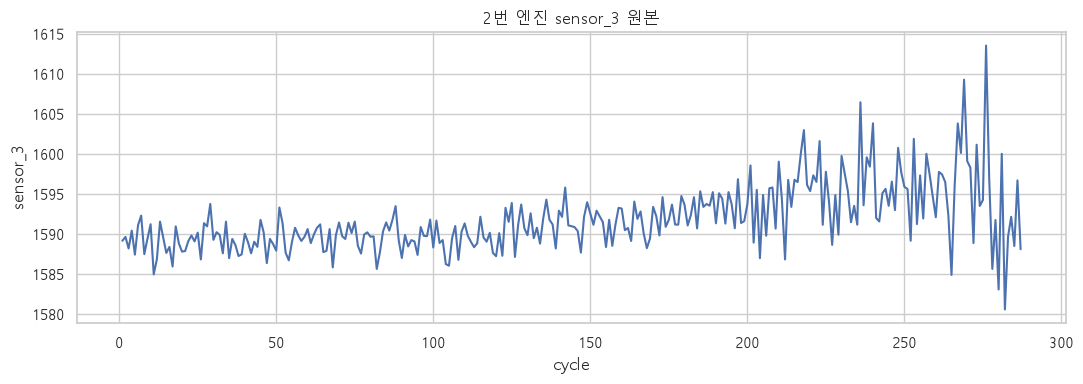

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(engine["time_cycles"], engine["sensor_3"])
plt.title("2번 엔진 sensor_3 원본")
plt.xlabel("cycle")
plt.ylabel("sensor_3")
plt.tight_layout()
plt.show()

### 🔍 이 그래프 읽는 법

**1. 초반**  
값이 일정 범위 안에서 비교적 잔잔하면 정상 상태 후보입니다.

**2. 후반**  
평균 수준이 움직이거나 흔들림 폭이 커지면 상태 변화 후보입니다.

**3. 중요한 점**  
그래프가 위로 올라간다고 해서 모든 센서에서 “나빠진다”는 뜻은 아닙니다.  
강의자료도 **온도는 상승하지만 압력은 하락할 수 있으므로 방향 자체보다 평소 패턴에서 벗어나는지**를 보라고 설명합니다.

# 7. 📈 이동평균 — 추세 읽기

```python
rolling(window).mean()
```

은 자잘한 노이즈를 주변 값과 섞어 **큰 흐름을 보기 쉽게** 합니다.

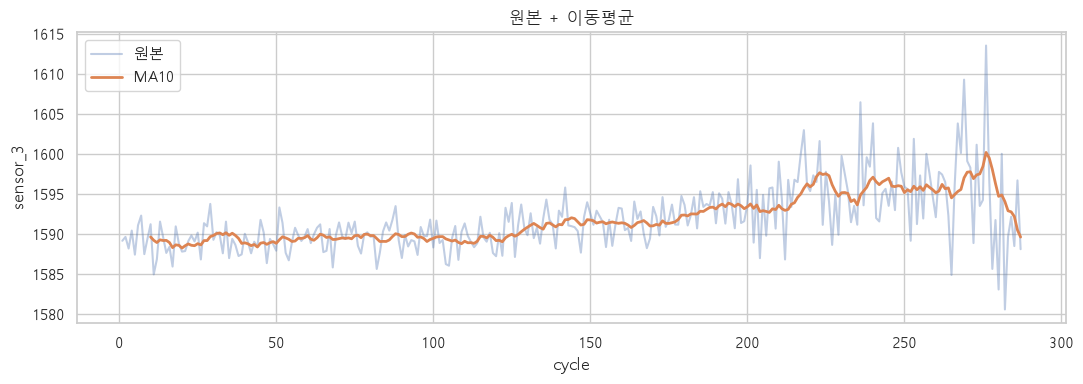

In [5]:
w = 10

engine["s3_ma10"] = engine["sensor_3"].rolling(w).mean()

plt.figure(figsize=(11, 4))
plt.plot(
    engine["time_cycles"],
    engine["sensor_3"],
    alpha=0.35,
    label="원본"
)
plt.plot(
    engine["time_cycles"],
    engine["s3_ma10"],
    linewidth=2,
    label="MA10"
)

plt.title("원본 + 이동평균")
plt.xlabel("cycle")
plt.ylabel("sensor_3")
plt.legend()
plt.tight_layout()
plt.show()

## 7-1. 이동평균 그래프에서 반드시 볼 3가지

### ① 방향
- 우상향 → 중심이 상승
- 우하향 → 중심이 하락
- 평평 → 큰 중심 변화가 적음

### ② 변곡점
평평하던 선이 기울기 시작하는 지점은  
**상태가 달라지기 시작한 후보 시점**입니다.

### ③ 원본과의 거리
원본 점들이 이동평균선에서 점점 멀리 출렁이면  
추세 변화와 별개로 **불안정성 증가**를 의심할 수 있습니다.

> 강의자료의 표현: **방향 · 변곡점 · 벗어남**

# 8. 🎚️ window 크기 비교

window는 **민감함 vs 부드러움**의 균형입니다.

- 작은 창 → 빨리 반응하지만 시끄러움
- 큰 창 → 매끈하지만 변화가 늦게 보임

강의자료는 수백 cycle 규모에서 **10~30을 무난한 출발점**으로 제시하지만, 정답은 아닙니다.

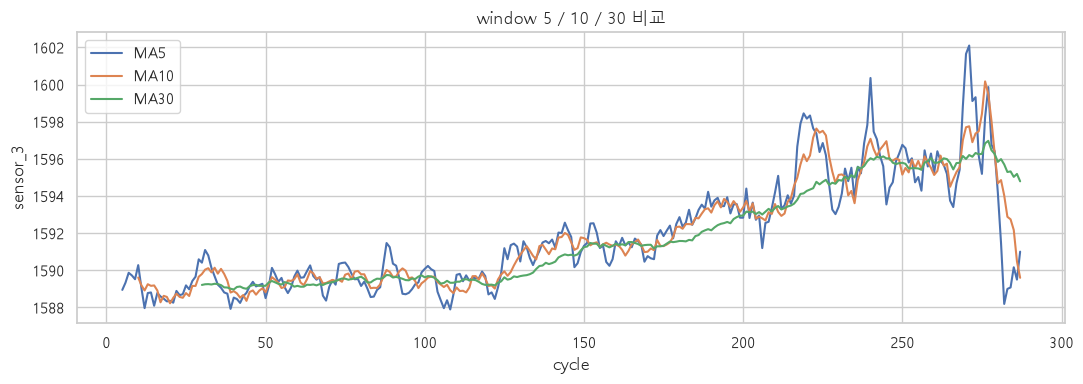

In [6]:
for w in [5, 10, 30]:
    engine[f"s3_ma{w}"] = engine["sensor_3"].rolling(w).mean()

plt.figure(figsize=(11, 4))

for w in [5, 10, 30]:
    plt.plot(
        engine["time_cycles"],
        engine[f"s3_ma{w}"],
        label=f"MA{w}"
    )

plt.title("window 5 / 10 / 30 비교")
plt.xlabel("cycle")
plt.ylabel("sensor_3")
plt.legend()
plt.tight_layout()
plt.show()

### 🔍 이 그래프에서 알아야 하는 것

- `MA5`가 훨씬 요동 → **노이즈가 아직 많이 남음**
- `MA30`이 부드러움 → **큰 흐름은 잘 보이지만 반응이 늦음**
- 변화 시작 시점을 빨리 잡고 싶으면 작은 창이 유리할 수 있음
- 장기 열화 방향만 보고 싶으면 큰 창이 유리할 수 있음

즉, **가장 예쁜 선이 정답이 아니라 목적에 맞는 선이 정답**입니다.

## 8-1. `min_periods`는 언제 쓰나?

기본 `rolling(10)`은 앞 9개가 NaN입니다.  
이는 오류가 아니라 **10개가 아직 모이지 않았기 때문**입니다.

앞부분도 계산하고 싶다면:

```python
rolling(10, min_periods=1).mean()
```

을 사용할 수 있습니다.

다만 초반은 1개·2개·3개만으로 계산된 값이므로 **후반과 같은 안정성을 가진 평균이 아닙니다.**

# 9. 🌊 이동표준편차 — 변동성 읽기

이동평균이:

> **어디로 가는가**

를 본다면 이동표준편차는:

> **얼마나 흔들리는가**

를 봅니다.

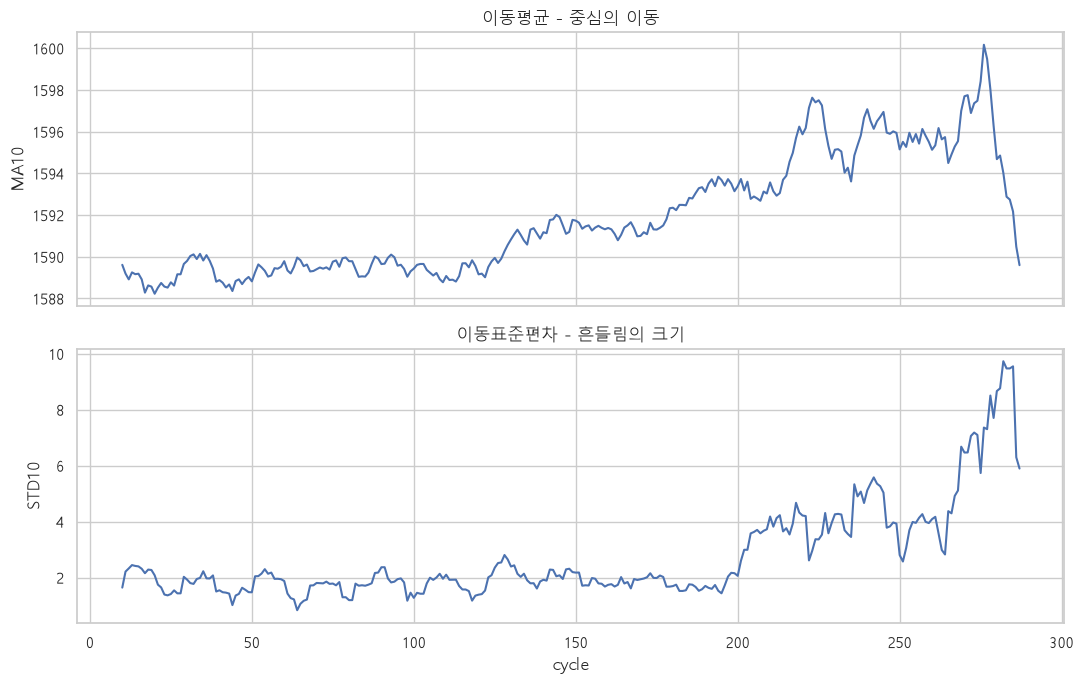

In [7]:
engine["s3_std10"] = engine["sensor_3"].rolling(10).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(engine["time_cycles"], engine["s3_ma10"])
axes[0].set_title("이동평균 - 중심의 이동")
axes[0].set_ylabel("MA10")

axes[1].plot(engine["time_cycles"], engine["s3_std10"])
axes[1].set_title("이동표준편차 - 흔들림의 크기")
axes[1].set_xlabel("cycle")
axes[1].set_ylabel("STD10")

plt.tight_layout()
plt.show()

## 9-1. 위·아래 그래프를 같이 읽는 방법

**위 칸 이동평균**
- 언제부터 선이 기울어졌는가?

**아래 칸 이동표준편차**
- 언제부터 값이 높아졌는가?

### 가장 중요한 경우
두 변화가 비슷한 시점에 나타나면  
강의자료에서는 **본격적인 상태 변화가 시작된 후보 구간**으로 봅니다.

### 조기 신호
이동표준편차가 이동평균보다 먼저 높아진다면  
추세가 뚜렷해지기 전에 **불안정성이 먼저 증가한 조기 신호**일 수 있습니다.

In [8]:
valid_std = engine["s3_std10"].dropna()

cut = len(valid_std) // 3
early_std = valid_std.iloc[:cut].mean()
late_std = valid_std.iloc[-cut:].mean()

print("초반 평균 변동성:", round(early_std, 3))
print("후반 평균 변동성:", round(late_std, 3))
print("후반/초반 배수:", round(late_std / early_std, 2))

초반 평균 변동성: 1.754
후반 평균 변동성: 4.628
후반/초반 배수: 2.64


# 10. ⚡ `diff()`와 `pct_change()` — 빠른 변화 찾기

## `diff()`
```text
현재값 - 직전값
```

→ **몇 만큼 변했는가**

## `pct_change()`
```text
(현재값 - 직전값) / 직전값
```

→ **몇 % 변했는가**

In [9]:
engine["s3_diff"] = engine["sensor_3"].diff()
engine["s3_pct"] = engine["sensor_3"].pct_change()

display(
    engine[
        ["time_cycles", "sensor_3", "s3_diff", "s3_pct"]
    ].head(8)
)

,time_cycles,sensor_3,s3_diff,s3_pct
0,1,1589.133807,NaN,NaN
1,2,1589.621597,0.487790,0.000307
2,3,1588.169676,-1.451921,-0.000913
3,4,1590.406441,2.236764,0.001408
4,5,1587.403982,-3.002459,-0.001888
5,6,1591.073814,3.669832,0.002312
6,7,1592.280175,1.206361,0.000758
7,8,1587.468159,-4.812016,-0.003022


## 10-1. 언제 `diff`, 언제 `pct_change`?

### `diff()`가 더 자연스러운 경우
- 같은 센서의 직전 대비 변화
- 단위 자체가 중요
- 크기가 비슷한 센서끼리 비교

### `pct_change()`가 더 자연스러운 경우
- 8짜리 센서와 640짜리 센서처럼 스케일이 크게 다름
- 절대 차이보다 상대적인 비율이 중요

### ⚠️ 주의
강의자료는 `pct_change()`에서 **직전 값이 0에 가까우면 비율이 불안정**할 수 있다고 강조합니다.

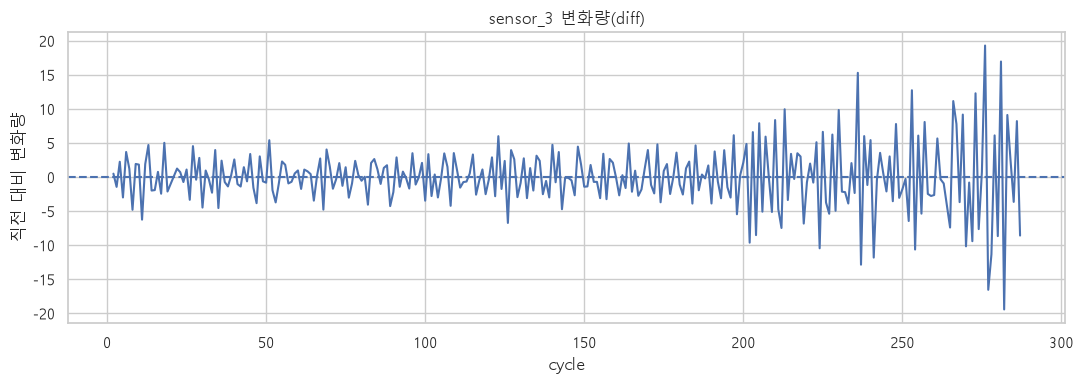

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(engine["time_cycles"], engine["s3_diff"])
plt.axhline(0, linestyle="--")
plt.title("sensor_3 변화량(diff)")
plt.xlabel("cycle")
plt.ylabel("직전 대비 변화량")
plt.tight_layout()
plt.show()

### 🔍 diff 그래프를 보는 법

- 대부분 0 근처 → 평소 변화
- 0에서 멀리 크게 튀는 봉우리 → **급변 후보**
- 양수 → 직전보다 상승
- 음수 → 직전보다 하락

하지만 큰 봉우리 하나만 보고 고장이라고 판단하지 않습니다.

강의자료의 순서:

```text
큰 봉우리 발견
→ 전후 원본 확인
→ 노이즈/센서 오류인지 확인
→ 다른 신호와 같이 확인
```

## 10-2. 노이즈가 너무 많으면 `이동평균 → diff`

강의자료 실습은 원본 `diff`뿐 아니라  
**이동평균을 먼저 구한 뒤 diff를 계산하면 잡음이 줄어드는지 확인**하도록 합니다.

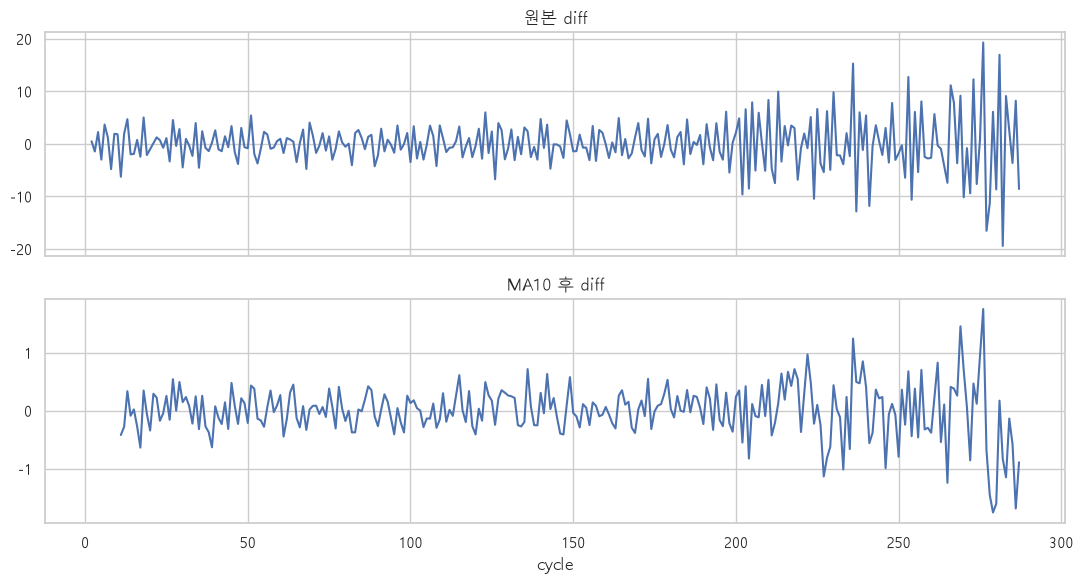

In [11]:
engine["s3_ma10_diff"] = engine["s3_ma10"].diff()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(engine["time_cycles"], engine["s3_diff"])
axes[0].set_title("원본 diff")

axes[1].plot(engine["time_cycles"], engine["s3_ma10_diff"])
axes[1].set_title("MA10 후 diff")
axes[1].set_xlabel("cycle")

plt.tight_layout()
plt.show()

### 상황별 선택

- **아주 순간적인 급변 자체가 중요** → 원본 `diff`
- **노이즈 때문에 봉우리가 너무 많음** → 이동평균 후 `diff`
- **단, 이동평균 후 diff는 매우 짧은 급변을 약하게 만들 수 있음**

즉, 빠른 이벤트를 잃으면 안 되는 경우에는 원본 그래프도 같이 봐야 합니다.

# 11. 🚩 잔차 기반 변화점 후보

강의자료의 단순 변화점 로직:

```text
1. 이동평균을 평소 기준선으로 사용
2. 원본 - 이동평균 = 잔차
3. 잔차가 평소 흔들림의 몇 배보다 크면 후보
```

In [12]:
w = 10
k = 2

roll_mean = engine["sensor_3"].rolling(w).mean()
residual = engine["sensor_3"] - roll_mean
threshold = k * residual.std()

change_mask = residual.abs() > threshold
change_cycles = engine.loc[change_mask, "time_cycles"]

print("잔차 표준편차:", round(residual.std(), 3))
print("임계값:", round(threshold, 3))
print("변화점 후보 개수:", int(change_mask.sum()))
print("후보 cycle 앞부분:", change_cycles.head(10).tolist())

잔차 표준편차: 3.135
임계값: 6.27
변화점 후보 개수: 13
후보 cycle 앞부분: [218, 224, 227, 236, 240, 265, 267, 269, 272, 276]


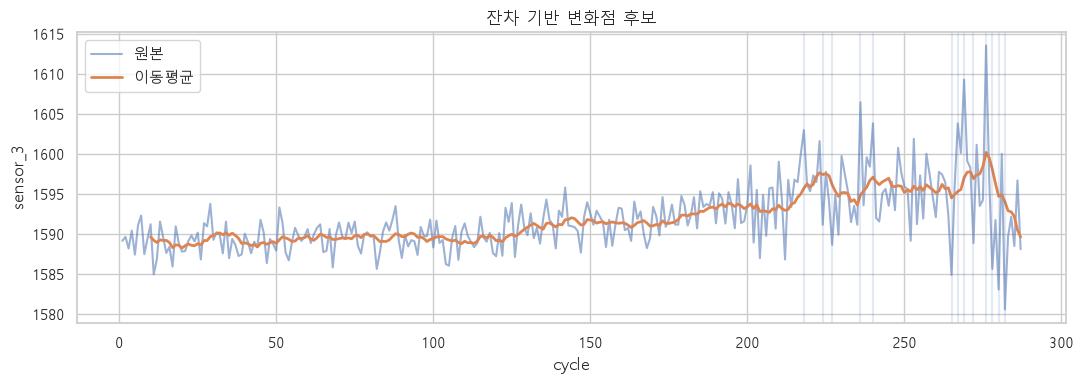

In [13]:
plt.figure(figsize=(11, 4))
plt.plot(
    engine["time_cycles"],
    engine["sensor_3"],
    alpha=0.55,
    label="원본"
)
plt.plot(
    engine["time_cycles"],
    roll_mean,
    linewidth=2,
    label="이동평균"
)

for c in change_cycles:
    plt.axvline(c, alpha=0.15)

plt.title("잔차 기반 변화점 후보")
plt.xlabel("cycle")
plt.ylabel("sensor_3")
plt.legend()
plt.tight_layout()
plt.show()

## 11-1. 변화점 그래프에서 알아야 하는 것

### 후보 개수보다 더 중요한 것: **어디에 몰렸는가**

- 전체 구간에 듬성듬성 → 일반 노이즈일 가능성도 있음
- 후반 특정 구간에 집중 → 상태 변화 근거가 더 강해짐

강의자료는 변화점을 **확정이 아니라 “더 살펴보라는 표지판”**으로 설명합니다.

## 11-2. 임계 배수 `k`를 바꾸면?

- `k` 작음 → 후보 많음 → 민감하지만 오탐 증가 가능
- `k` 큼 → 후보 적음 → 엄격하지만 작은 변화 놓칠 수 있음

강의자료에서는 **창 크기와 임계값 배수**를 변화점 탐지의 두 손잡이라고 설명합니다.

In [14]:
def count_change_points(series, window=10, k=2):
    ma = series.rolling(window).mean()
    residual = series - ma
    threshold = k * residual.std()
    return int((residual.abs() > threshold).sum())

results = []

for window in [5, 10, 20, 30]:
    for k in [1.5, 2.0, 3.0]:
        results.append({
            "window": window,
            "k": k,
            "변화점 개수": count_change_points(
                engine["sensor_3"],
                window=window,
                k=k
            )
        })

display(pd.DataFrame(results))

,window,k,변화점 개수
0,5,1.5,25
1,5,2.0,15
2,5,3.0,7
3,10,1.5,24
4,10,2.0,13
5,10,3.0,7
6,20,1.5,23
7,20,2.0,13
8,20,3.0,7
9,30,1.5,23


# 12. 📅 cycle과 timestamp

강의자료는:
- cycle → 작동 횟수
- timestamp → 실제 날짜·시각

으로 구분합니다.

`rolling`, `corr` 등 순서 기반 도구는 cycle에서도 가능하지만,  
**하루·6시간 같은 리샘플링은 timestamp가 있어야 합니다.**

아래는 강의와 같은 방식으로 **1 cycle = 1시간**이라고 가정한 학습용 가상 timestamp입니다.

In [15]:
ts = engine.copy()

start = pd.Timestamp("2024-01-01 00:00:00")

ts["timestamp"] = (
    start
    + pd.to_timedelta(
        ts["time_cycles"] - 1,
        unit="h"
    )
)

ts["timestamp"] = pd.to_datetime(ts["timestamp"])
ts = ts.set_index("timestamp").sort_index()

print(type(ts.index).__name__)
display(ts.head())

DatetimeIndex


,unit_number,time_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_20,s3_ma10,s3_ma5,s3_ma30,s3_std10,s3_diff,s3_pct,s3_ma10_diff
timestamp,,,,,,,,,,,,,,,
2024-01-01 00:00:00,2,1,642.645542,1589.133807,1398.966768,553.920782,46.163269,39.054961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,2,2,642.682118,1589.621597,1397.763429,553.748991,45.904832,38.947132,NaN,NaN,NaN,NaN,0.487790,0.000307,NaN
2024-01-01 02:00:00,2,3,642.516558,1588.169676,1401.232512,553.807856,45.882835,38.834552,NaN,NaN,NaN,NaN,-1.451921,-0.000913,NaN
2024-01-01 03:00:00,2,4,642.935608,1590.406441,1400.543028,554.130802,46.057200,39.042290,NaN,NaN,NaN,NaN,2.236764,0.001408,NaN
2024-01-01 04:00:00,2,5,640.668442,1587.403982,1401.338211,553.988352,45.845384,38.765990,NaN,1588.947101,NaN,NaN,-3.002459,-0.001888,NaN


## 12-1. `resample()`에서 평균과 최대를 같이 보는 이유

강의자료는 설비에서는 **평균보다 최댓값이 중요할 때가 많으므로 평균과 최댓값을 함께 보라**고 설명합니다.

- 평균 → 전체 수준과 큰 추세
- 최대 → 짧은 위험 피크

,mean,max
timestamp,,
2024-01-01,1588.925039,1592.280175
2024-01-02,1589.275430,1593.738912
2024-01-03,1589.482420,1593.294285
2024-01-04,1589.588370,1593.461327
2024-01-05,1589.245014,1592.136715


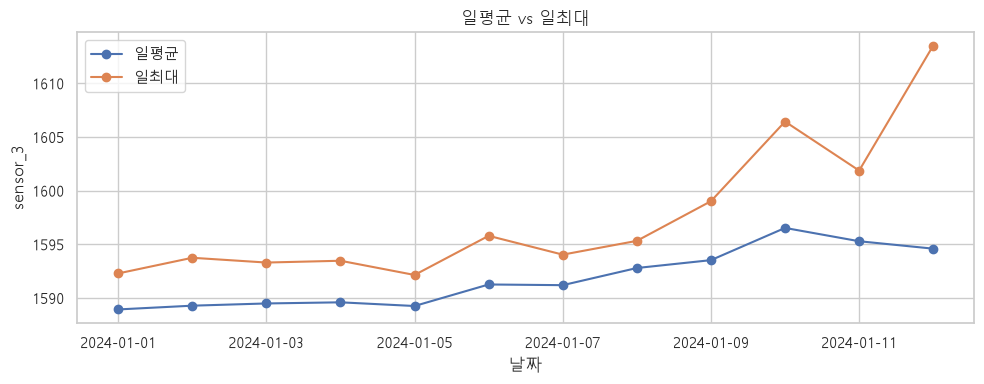

In [16]:
daily = ts["sensor_3"].resample("D").agg(["mean", "max"])

display(daily.head())

plt.figure(figsize=(10, 4))
plt.plot(daily.index, daily["mean"], marker="o", label="일평균")
plt.plot(daily.index, daily["max"], marker="o", label="일최대")
plt.title("일평균 vs 일최대")
plt.xlabel("날짜")
plt.ylabel("sensor_3")
plt.legend()
plt.tight_layout()
plt.show()

### 🔍 이 그래프에서 알아야 하는 것

- 평균과 최대가 같이 올라감 → 전반적인 수준 자체가 상승
- 평균은 비슷한데 최대만 튐 → 짧은 피크가 존재할 가능성
- 너무 큰 시간 단위로 묶으면 순간 급변이 평균에 녹아 사라질 수 있음

그래서 **긴 추세는 평균**, **안전상 피크가 중요하면 최대도 함께** 보는 것이 좋습니다.

# 13. 📏 여러 센서를 비교하려면 먼저 눈금 맞추기

640 근처 센서와 8 근처 센서를 같은 y축에 바로 그리면  
작은 센서는 거의 직선처럼 보입니다.

강의자료는 이를 해결하기 위해 **Min-Max 정규화**를 사용합니다.

```python
(x - x.min()) / (x.max() - x.min())
```

In [17]:
sensor_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_20']

norm = engine[sensor_cols].copy()

for col in sensor_cols:
    x = norm[col]
    norm[col] = (x - x.min()) / (x.max() - x.min())

print("정규화 최솟값:")
print(norm.min().round(3))

print("\n정규화 최댓값:")
print(norm.max().round(3))

정규화 최솟값:
sensor_2     0.0
sensor_3     0.0
sensor_4     0.0
sensor_7     0.0
sensor_11    0.0
sensor_20    0.0
dtype: float64

정규화 최댓값:
sensor_2     1.0
sensor_3     1.0
sensor_4     1.0
sensor_7     1.0
sensor_11    1.0
sensor_20    1.0
dtype: float64


## 13-1. 정규화 그래프를 어떻게 읽나?

정규화 후에는 실제 단위가 아니라:

> **자기 범위에서 어디쯤 위치하는가**

를 비교합니다.

- 0 → 해당 센서의 관측 최소 수준
- 1 → 해당 센서의 관측 최대 수준
- 같은 시점에 여러 선이 함께 위로 → 함께 상승하는 무리
- 한 선만 반대로 내려감 → 반대 관계 후보

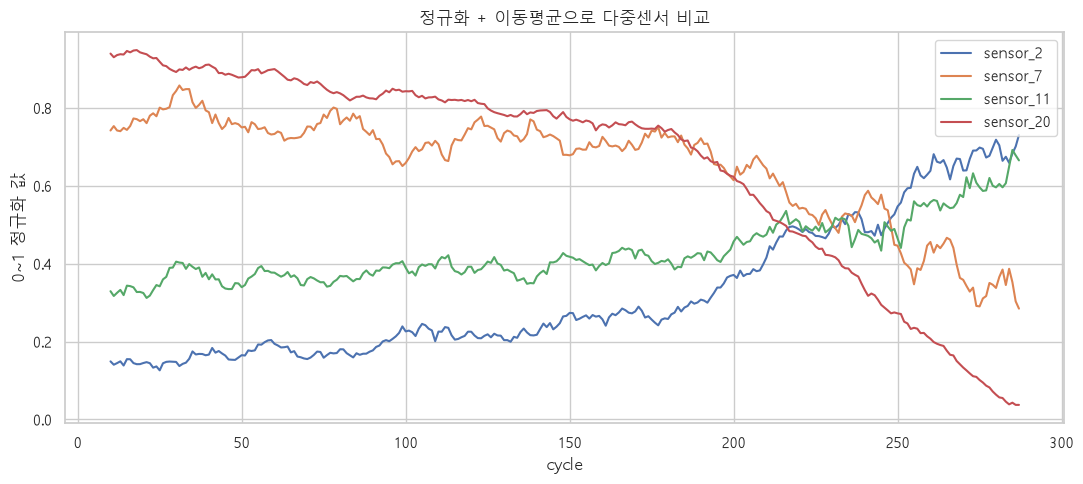

In [18]:
compare_cols = [
    "sensor_2",
    "sensor_7",
    "sensor_11",
    "sensor_20"
]

norm_ma = norm[compare_cols].rolling(10).mean()

plt.figure(figsize=(11, 5))

for col in compare_cols:
    plt.plot(
        engine["time_cycles"],
        norm_ma[col],
        label=col
    )

plt.title("정규화 + 이동평균으로 다중센서 비교")
plt.xlabel("cycle")
plt.ylabel("0~1 정규화 값")
plt.legend()
plt.tight_layout()
plt.show()

## 13-2. 다중 센서 비교 그래프에서 볼 3가지

### ① 함께 가는 선
같은 시점에 같이 상승/하락  
→ 같은 현상을 반영할 가능성

### ② 반대로 가는 선
한쪽 상승, 한쪽 하락  
→ 서로 반대 방향으로 연결된 현상 가능성

### ③ 같은 시점의 변화
여러 센서가 **비슷한 cycle부터 동시에 방향을 바꾸면**  
한 센서만의 우연한 튐보다 실제 설비 상태 변화일 가능성이 높아집니다.

이것이 다음 단계인 상관관계의 **눈으로 보는 버전**입니다.

## 13-3. Min-Max 정규화 주의점

강의자료는 두 가지를 명확히 강조합니다.

1. 실제 단위가 0~1 비율로 바뀌므로 **실제 값이 필요할 때는 원본 사용**
2. 이상치 하나가 최댓값이 되면 나머지 값이 눌릴 수 있으므로 **정규화 전에 이상치 점검**

즉, 정규화는 **센서 모양 비교용**이지 원본을 대체하는 것이 아닙니다.

# 14. 📊 초반·후반 변화 폭으로 감시 센서 찾기

강의자료의 실습은 각 센서의 초반·후반 평균 차이를 비교해  
**변화 폭이 큰 센서**를 감시 후보로 찾습니다.

In [19]:
norm_ma_all = norm.rolling(10).mean()

valid = norm_ma_all.dropna()
n_block = max(20, len(valid) // 5)

early = valid.iloc[:n_block].mean()
late = valid.iloc[-n_block:].mean()

change = (late - early).sort_values(key=lambda s: s.abs(), ascending=False)

change_table = pd.DataFrame({
    "초반 평균": early,
    "후반 평균": late,
    "후반-초반": late - early
}).loc[change.index]

display(change_table.round(3))

,초반 평균,후반 평균,후반-초반
sensor_20,0.907,0.204,-0.703
sensor_4,0.171,0.742,0.571
sensor_2,0.162,0.608,0.447
sensor_7,0.772,0.428,-0.344
sensor_3,0.261,0.458,0.197
sensor_11,0.359,0.545,0.185


### 🔍 이 표에서 알아야 하는 것

- `후반-초반`이 큰 양수 → 크게 상승
- 큰 음수 → 크게 하락
- 절댓값이 크다 → 상태 변화 감시에 더 민감한 센서 후보

하지만 **변화 폭이 크다는 이유만으로 좋은 센서라고 확정할 수는 없습니다.**  
센서의 물리적 의미와 정상 동작 방향도 같이 확인해야 합니다.

# 15. 🔗 상관관계

상관계수는 두 센서가 함께 움직이는 정도를 `-1 ~ 1`로 나타냅니다.

- 양수 → 같은 방향
- 음수 → 반대 방향
- 절댓값이 1에 가까울수록 강함

강의자료에서는 보통 **|r| ≥ 0.7**을 강한 상관의 예로 설명합니다.

In [20]:
corr = engine[sensor_cols].corr()

display(corr.round(2))

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_20
sensor_2,1.00,0.47,0.85,-0.84,0.65,-0.89
sensor_3,0.47,1.00,0.48,-0.42,0.31,-0.54
sensor_4,0.85,0.48,1.00,-0.72,0.52,-0.91
sensor_7,-0.84,-0.42,-0.72,1.00,-0.52,0.75
sensor_11,0.65,0.31,0.52,-0.52,1.00,-0.57
sensor_20,-0.89,-0.54,-0.91,0.75,-0.57,1.00


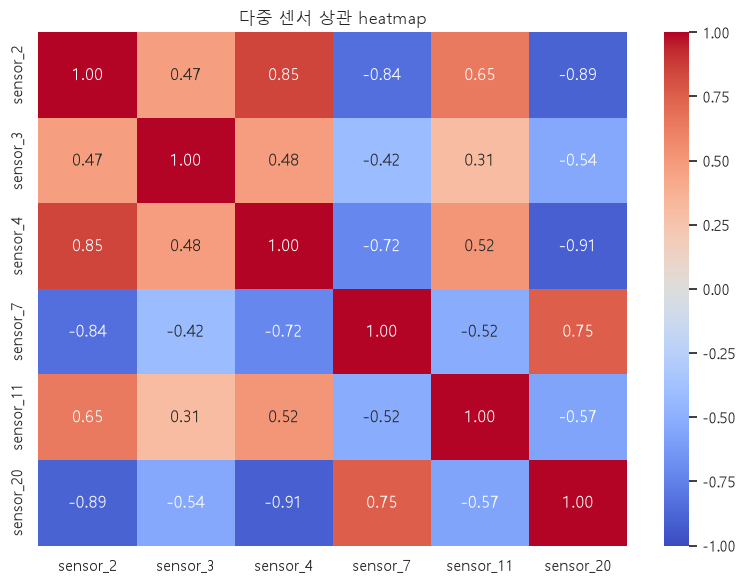

In [21]:
if SEABORN_OK:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0
    )
    plt.title("다중 센서 상관 heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("seaborn이 설치되지 않아 heatmap 셀을 건너뜁니다.")
    print(corr.round(2))

## 15-1. heatmap은 이렇게 읽기

### ① 대각선 무시
자기 자신과의 상관이라 항상 `1`

### ② 진한 양수
함께 움직이는 센서쌍

### ③ 진한 음수
반대 방향으로 움직이는 센서쌍

### ④ 연한 색
선형 상관이 약한 관계

### ⑤ 덩어리
여러 센서가 진한 색으로 묶이면  
**같은 현상을 함께 반영하는 센서 그룹**일 수 있습니다.

## 15-2. 상관계수 0 = 완전한 무관은 아님

강의자료는 상관계수가 0에 가까워도  
**곡선형 관계는 Pearson 상관으로 잘 안 잡힐 수 있으므로 그래프 확인이 필요**하다고 설명합니다.

따라서:

```text
corr로 숫자 확인
→ 필요하면 scatter 등 그래프로 관계 모양 확인
```

의 흐름이 안전합니다.

## 15-3. 강한 양/음 센서쌍 자동 추출

In [22]:
pairs = []

for i, a in enumerate(sensor_cols):
    for b in sensor_cols[i+1:]:
        pairs.append({
            "센서A": a,
            "센서B": b,
            "상관계수": corr.loc[a, b]
        })

pair_df = pd.DataFrame(pairs)

print("[가장 강한 양의 상관]")
display(
    pair_df.sort_values("상관계수", ascending=False).head(5)
)

print("[가장 강한 음의 상관]")
display(
    pair_df.sort_values("상관계수", ascending=True).head(5)
)

[가장 강한 양의 상관]


,센서A,센서B,상관계수
1,sensor_2,sensor_4,0.848399
13,sensor_7,sensor_20,0.752563
3,sensor_2,sensor_11,0.646917
10,sensor_4,sensor_11,0.516025
5,sensor_3,sensor_4,0.481687


[가장 강한 음의 상관]


,센서A,센서B,상관계수
11,sensor_4,sensor_20,-0.909947
4,sensor_2,sensor_20,-0.893858
2,sensor_2,sensor_7,-0.839616
9,sensor_4,sensor_7,-0.720599
14,sensor_11,sensor_20,-0.566318


## 15-4. ⚠️ 상관관계는 인과관계가 아니다

두 센서가 함께 변한다고 해서:

> `sensor_2가 sensor_11을 변화시킨다`

라고 말할 수는 없습니다.

강의자료의 핵심:

> **상관은 관계 발견의 출발점이지 결론이 아니다.**

두 센서 모두에 영향을 주는 **제3의 공통 원인**이 있을 수 있습니다.

# 16. 🚨 이상 의심 구간 — 여러 신호를 겹쳐 보기

강의자료의 종합 판단 기준은 4가지입니다.

1. **추세 꺾임** — 이동평균 기울기 변화
2. **변동성 증가** — 이동표준편차 상승
3. **변화점 집중** — 변화점 후보가 한 구간에 몰림
4. **센서 관계 변화** — 함께 가던 센서 패턴이 깨짐

> 한 신호만으로는 노이즈일 수 있지만, 여러 신호가 같은 구간에 겹칠수록 의심이 강해집니다.

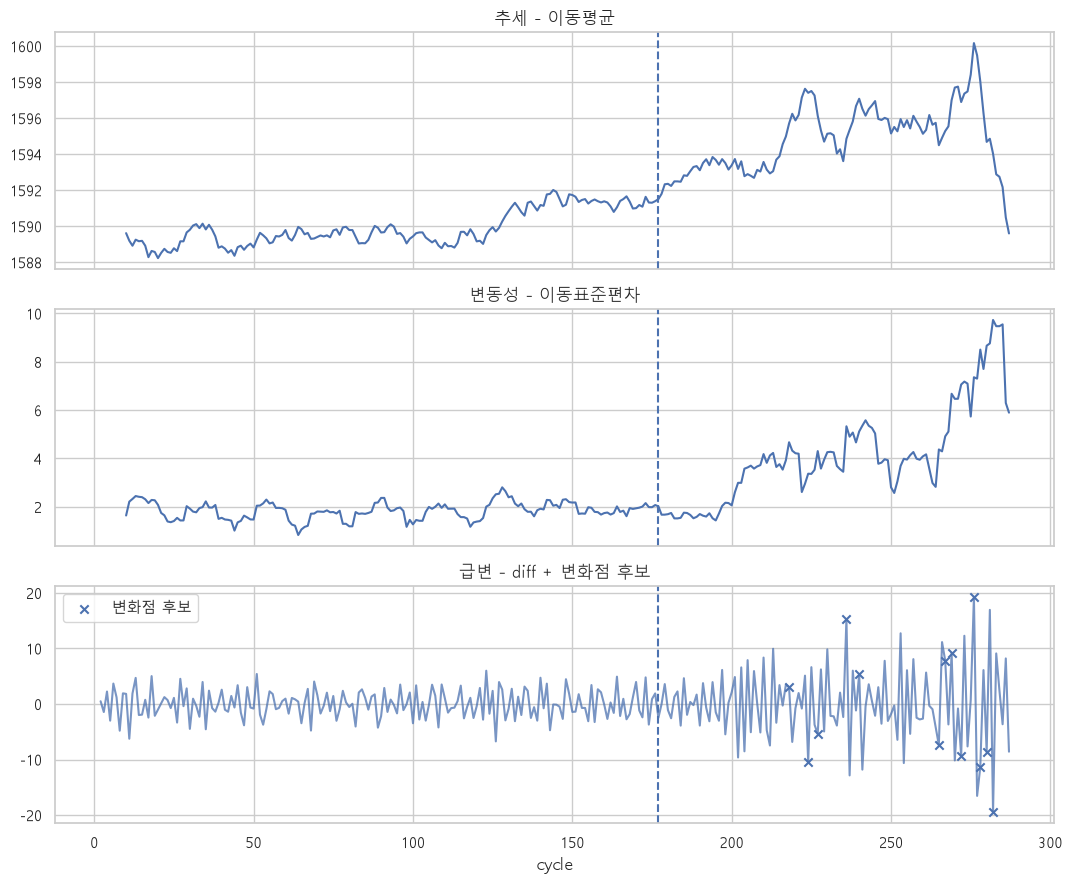

In [23]:
# 합성 데이터 생성 규칙에서 상태 변화가 시작되도록 만든 구간
demo_change_start = int(len(engine) * 0.62)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(
    engine["time_cycles"],
    engine["s3_ma10"]
)
axes[0].axvline(demo_change_start, linestyle="--")
axes[0].set_title("추세 - 이동평균")

axes[1].plot(
    engine["time_cycles"],
    engine["s3_std10"]
)
axes[1].axvline(demo_change_start, linestyle="--")
axes[1].set_title("변동성 - 이동표준편차")

axes[2].plot(
    engine["time_cycles"],
    engine["s3_diff"],
    alpha=0.75
)
axes[2].scatter(
    engine.loc[change_mask, "time_cycles"],
    engine.loc[change_mask, "s3_diff"],
    marker="x",
    label="변화점 후보"
)
axes[2].axvline(demo_change_start, linestyle="--")
axes[2].set_title("급변 - diff + 변화점 후보")
axes[2].set_xlabel("cycle")
axes[2].legend()

plt.tight_layout()
plt.show()

## 16-1. 이 3단 그래프를 읽는 순서

### 1단: 추세
평평했던 선이 언제부터 기울어지는가?

### 2단: 변동성
그 시기 전후로 흔들림도 커졌는가?

### 3단: 변화점
급변 후보가 그 구간에 몰렸는가?

세 신호가 같은 구간을 가리키면  
단일 그래프보다 훨씬 강한 상태 변화 근거가 됩니다.

# 17. 🔄 센서 관계 변화도 이상 신호가 될 수 있다

강의자료는 **평소 강하게 상관되던 센서 관계가 깨지는 것 자체**도 이상 신호가 될 수 있다고 설명합니다.

아래처럼 초반/후반 상관을 비교할 수 있습니다.

In [24]:
split = int(len(engine) * 0.5)

early_corr = engine.iloc[:split][sensor_cols].corr()
late_corr = engine.iloc[split:][sensor_cols].corr()

corr_change = (late_corr - early_corr).abs()

print("초반 sensor_2 ↔ sensor_11:",
      round(early_corr.loc["sensor_2", "sensor_11"], 3))
print("후반 sensor_2 ↔ sensor_11:",
      round(late_corr.loc["sensor_2", "sensor_11"], 3))

print("\n상관 변화 절댓값 상위:")
pairs_change = []

for i, a in enumerate(sensor_cols):
    for b in sensor_cols[i+1:]:
        pairs_change.append({
            "센서A": a,
            "센서B": b,
            "|후반-초반 상관|": corr_change.loc[a, b]
        })

display(
    pd.DataFrame(pairs_change)
    .sort_values("|후반-초반 상관|", ascending=False)
    .head(5)
)

초반 sensor_2 ↔ sensor_11: 0.476
후반 sensor_2 ↔ sensor_11: 0.534

상관 변화 절댓값 상위:


,센서A,센서B,|후반-초반 상관|
13,sensor_7,sensor_20,0.570985
4,sensor_2,sensor_20,0.539061
9,sensor_4,sensor_7,0.511451
1,sensor_2,sensor_4,0.450773
11,sensor_4,sensor_20,0.372984


### 주의
상관 변화가 크다고 바로 고장이라고 할 수는 없습니다.

운전 조건 자체가 바뀌어 관계가 달라졌을 수도 있으므로  
**추세·변동성·변화점과 함께** 봅니다.

# 18. 🧭 상황에 맞는 코드 선택

| 상황 | 더 적합한 시작 코드 | 이유 |
|---|---|---|
| 천천히 열화 | `rolling().mean()` | 노이즈를 줄여 장기 방향 확인 |
| 불안정성이 커짐 | `rolling().std()` | 흔들림 크기 추적 |
| 순간 급변 | `.diff()` | 직전 대비 급격한 변화 |
| 센서 크기 차이가 큼 | `.pct_change()` | 비율로 비교 |
| 노이즈가 너무 많아 diff가 난잡 | `rolling().mean().diff()` | 흐름을 먼저 다듬고 변화량 |
| 변화점 후보 자동화 | 잔차 + `k*std` | 평소 대비 벗어남 |
| 실제 시간 단위 분석 | timestamp + `resample()` | 하루/6시간 집계 |
| 장기 추세 | `resample().mean()` | 대표 수준 |
| 위험 피크 | `resample().max()` | 평균에 묻히는 순간 최대값 |
| 여러 센서 모양 비교 | Min-Max + rolling | 스케일 제거 + 노이즈 완화 |
| 센서 관계 숫자화 | `.corr()` | 함께/반대 움직임 정량화 |
| 센서 관계 한눈에 | `heatmap()` | 강한 관계 시각 탐색 |

## 18-1. 추가적으로 알아두면 좋은 점

아래는 **강의 내용을 바탕으로 한 일반적인 Pandas 활용 팁**이며, 강의자료의 실습 결과 자체는 아닙니다.

### 원본 열은 보존
```python
engine["ma10"] = engine["sensor_3"].rolling(10).mean()
```

처럼 새 열에 저장하면 원본과 가공값을 비교하기 쉽습니다.

### 열 이름에 window 적기
```python
ma5, ma10, ma30
std10
```

처럼 이름만 봐도 조건을 알 수 있게 하면 혼동이 줄어듭니다.

### 분석 파라미터를 기록
변화점 결과는 `window`, `k`에 따라 달라지므로 리포트에 같이 기록하는 편이 재현에 유리합니다.

# 19. 👁️ 그래프를 보고 무엇을 알아야 하나? — 최종 체크표

## 선 그래프
```text
방향 → 기울기 → 변곡점 → 흔들림 → 급변
```

질문:
- 초반과 후반 중심이 다른가?
- 언제부터 방향이 달라지는가?
- 후반 흔들림이 커졌는가?

## 이동평균
```text
어느 방향으로 가는가?
언제 기울기 시작하는가?
```

## 이동표준편차
```text
높이가 올라가는가?
언제부터 올라가는가?
```

## diff
```text
0에서 크게 튀는 곳은 어디인가?
그 직전·직후 원본은 실제로 이상한가?
```

## 다중센서 정규화 그래프
```text
함께 가는 선?
반대로 가는 선?
같은 시점에 꺾이는가?
```

## heatmap
```text
대각선 제외
진한 양수?
진한 음수?
진한 색 덩어리?
```

## 종합
```text
추세 + 변동성 + 변화점 + 센서관계
같은 구간을 가리키는가?
```

# 20. 📝 분석 결과를 정비 언어로 바꾸기

강의자료는 통계 용어 자체보다:

```text
무엇
언제
의미
행동
```

이 들어가야 리포트 가치가 생긴다고 설명합니다.

## 예시

### ❌ 분석가식 표현
> 이동평균이 상승하고 이동표준편차가 증가했다.

### ✅ 정비 담당자가 이해하기 쉬운 표현
> `sensor_3`의 평균 수준이 후반부부터 점진적으로 상승했고, 같은 구간에서 흔들림도 커졌습니다. 여러 변화점 후보가 후반부에 집중되어 상태 변화가 의심되므로 해당 구간의 운전 기록과 관련 부품을 우선 점검하는 것이 좋습니다.

### 중요
- 관찰 → 데이터 사실
- 해석 → 가능성 / 추정
- 권장 → 실제 행동

**“고장이다”라고 단정하지 않습니다.**

In [25]:
# 합성 데모용 간단 요약

valid_std = engine["s3_std10"].dropna()
block = len(valid_std) // 3

early_vol = valid_std.iloc[:block].mean()
late_vol = valid_std.iloc[-block:].mean()

half_cycle = engine["time_cycles"].median()
late_change_ratio = (
    engine.loc[change_mask, "time_cycles"] > half_cycle
).mean()

print("=== 합성 데모 상태 요약 ===")
print(f"대상: 2번 엔진 / sensor_3")
print(f"초반 평균 변동성: {early_vol:.3f}")
print(f"후반 평균 변동성: {late_vol:.3f}")
print(f"후반/초반 변동성 배수: {late_vol/early_vol:.2f}")
print(f"변화점 후보 개수: {int(change_mask.sum())}")
print(f"변화점 중 후반부 비율: {late_change_ratio:.1%}")

print("\n[해석]")
print("후반부의 변동성과 변화점 집중 여부를 다른 센서와 함께 확인하세요.")

=== 합성 데모 상태 요약 ===
대상: 2번 엔진 / sensor_3
초반 평균 변동성: 1.754
후반 평균 변동성: 4.628
후반/초반 변동성 배수: 2.64
변화점 후보 개수: 13
변화점 중 후반부 비율: 100.0%

[해석]
후반부의 변동성과 변화점 집중 여부를 다른 센서와 함께 확인하세요.


# 21. ⚡ 시험/실무 핵심 포인트 & 오해하기 쉬운 점

### ① 값 하나가 크다고 이상은 아님
평소 대비 변화가 핵심

### ② 여러 엔진을 이어 그리면 가짜 변화가 생김
항상 설비 한 대씩

### ③ `rolling` 앞부분 NaN은 정상
window가 아직 채워지지 않음

### ④ 큰 window가 무조건 좋지 않음
매끈하지만 반응이 늦음

### ⑤ 이동평균과 이동표준편차는 다른 정보
- 중심 이동
- 흔들림 증가

### ⑥ `diff()` 첫 값 NaN은 정상
직전 값 없음

### ⑦ `pct_change()`는 직전 값이 0 근처면 불안정
비율 해석 주의

### ⑧ 변화점 = 고장 확정 아님
의심 후보

### ⑨ 리샘플링 단위가 너무 크면 급변이 사라질 수 있음
평균과 최대를 목적에 따라 비교

### ⑩ Min-Max 정규화는 실제 단위를 없앰
실제 수치는 원본에서 확인

### ⑪ 이상치가 Min-Max를 왜곡할 수 있음
정규화 전에 이상치 확인

### ⑫ 상관계수 0이 모든 관계 없음은 아님
곡선 관계는 그래프 확인 필요

### ⑬ 상관 ≠ 인과
관계 발견이지 원인 확정이 아님

### ⑭ 가장 강한 이상 근거
여러 신호가 **같은 구간에서 동시에 변화**

# 22. 🧠 마지막 암기 카드

```text
한 설비
→ filter
→ sort

추세
→ rolling().mean()

변동성
→ rolling().std()

급변
→ diff()

비율 변화
→ pct_change()

변화점
→ residual
→ threshold

시간 집계
→ timestamp
→ resample

다중센서 비교
→ min-max
→ rolling
→ 한 화면

관계
→ corr
→ heatmap

최종 판단
→ 추세 꺾임
→ 변동성 증가
→ 변화점 집중
→ 센서 관계 변화

그래프 읽기
→ 방향
→ 흔들림
→ 급변
→ 언제부터
→ 여러 신호가 같이 변했나
```

# 23. 🔍 1분 셀프 체크

### Q1.
이동평균은 평평한데 이동표준편차가 계속 상승합니다. 무엇을 알 수 있을까요?

**정답:** 중심 수준은 아직 크게 변하지 않았지만 흔들림이 커져 **불안정성이 증가하는 조기 신호 후보**로 볼 수 있습니다.

---

### Q2.
`diff()` 그래프에서 큰 봉우리 하나가 발견됐습니다. 바로 고장이라고 할 수 있을까요?

**정답:** 아니요. 전후 원본값, 노이즈, 센서 오류, 다른 센서 신호를 함께 확인해야 합니다.

---

### Q3.
정규화한 여러 센서가 같은 cycle부터 함께 방향을 바꿨습니다. 왜 중요한가요?

**정답:** 한 센서만의 우연한 변화보다 **실제 설비 상태가 함께 변했을 가능성**이 커집니다.

---

### Q4.
heatmap에서 대각선이 모두 1인 이유는?

**정답:** 각 센서가 자기 자신과 완벽하게 같은 값이므로 자기상관은 1입니다.

# 24. 🎯 종합 실습

합성 데이터 `engine`을 사용해 직접 분석해 보세요.

1. `sensor_2`의 MA5, MA10, MA30 비교
2. `sensor_3`의 이동표준편차 계산
3. 초반/후반 변동성 평균 비교
4. `sensor_3.diff()`에서 절댓값 상위 5개 cycle 출력
5. `sensor_2.pct_change()` 계산
6. 잔차 기반 변화점 후보 찾기
7. window와 임계 배수를 바꿔 후보 수 비교
8. 가상 timestamp로 하루 평균/최대 비교
9. 4개 센서를 Min-Max 정규화 후 겹쳐 그리기
10. 상관 heatmap에서 가장 강한 양/음 쌍 찾기
11. 초반/후반 상관 변화를 비교
12. 마지막에 아래 형식으로 리포트 작성

```text
[관찰]
[구간]
[해석]
[권장]
```

---
## 📚 출처 및 작성 원칙

이 노트의 강의 개념과 구조는 아래 두 자료를 기준으로 정리했습니다.

### 23_01 상태 변화 추적
- 절대값보다 변화의 흐름
- 단일 설비 분석
- 이동평균 / 이동표준편차
- window와 min_periods
- diff / pct_change
- 잔차 기반 변화점
- 변화점의 민감도

### 23_02 다중센서 패턴 분석
- cycle과 timestamp
- 시간 인덱싱 / 리샘플링
- Min-Max 정규화
- 다중 센서 비교
- 상관계수 / heatmap
- 상관과 인과의 구분
- 여러 신호를 종합한 이상 의심 구간
- 정비 리포트

### 이 노트에서 추가한 부분
사용자가 요청한 **“그래프나 데이터를 보고 무엇을 알아야 하는지”**를 돕기 위해:

- 그래프별 읽는 순서
- 상황별 코드 선택표
- 원본 vs 이동평균 diff 비교
- 평균 vs 최대 리샘플링 비교
- 상관관계 초반/후반 비교
- 합성 데이터로 실제 실행 결과와 그래프

를 추가했습니다.

이 추가 예시는 **강의의 실제 CSV 결과가 아니라 학습용 합성 데모**입니다.